### <CENTER> GOLD PURITY ESTIMATOR </CENTER>

#### Setup

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [42]:
IMAGE_PATH = "images/"

#### Volume Measurement - Prototype

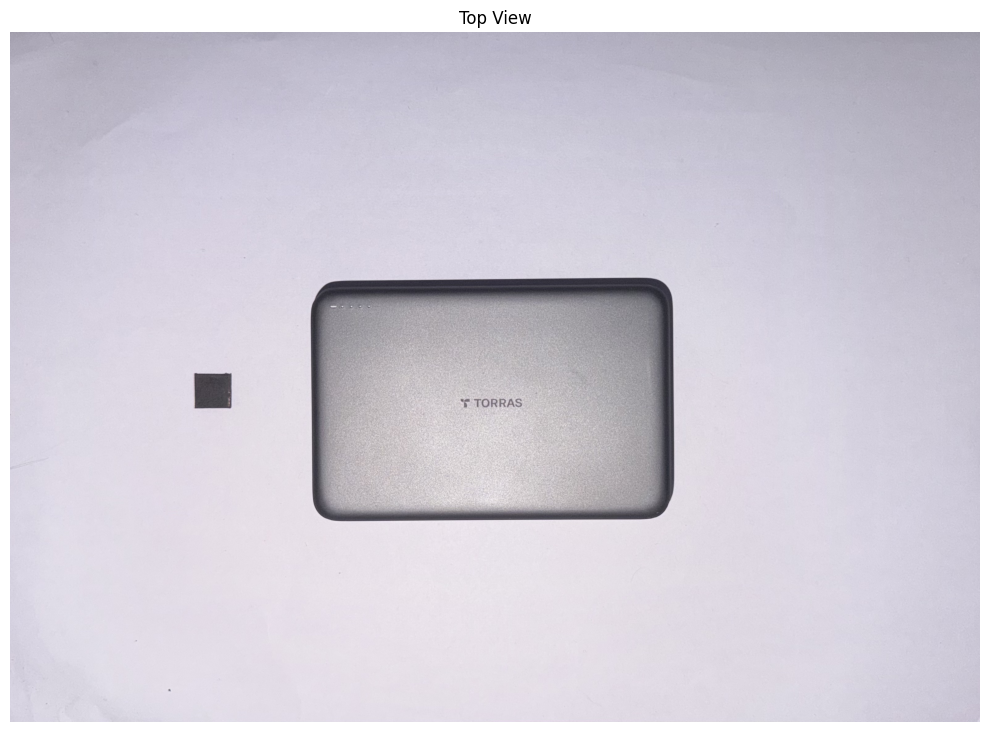

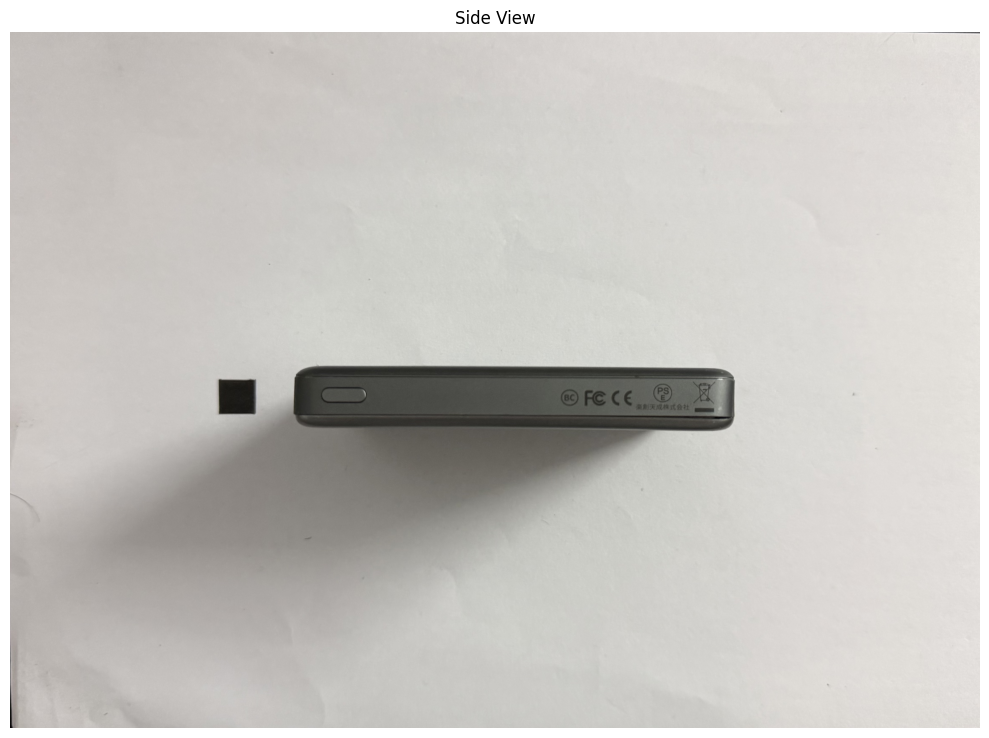

In [ ]:
# Show images
top_view_path = IMAGE_PATH + "IMG_0290.jpeg"
side_view_path = IMAGE_PATH + "IMG_0303.jpeg"

top_view = cv2.imread(top_view_path)
side_view = cv2.imread(side_view_path)

# Check if images loaded successfully
if top_view is None:
    print(f"Error: Could not load image from {top_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(top_view, cv2.COLOR_BGR2RGB))
    plt.title("Top View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if side_view is None:
    print(f"Error: Could not load image from {side_view_path}")
    print("Note: OpenCV may not support HEIC format. Convert to JPG/PNG first.")
else:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(side_view, cv2.COLOR_BGR2RGB))
    plt.title("Side View")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [44]:
def compute_scale_from_ref(img, real_size_cm=1.0, debug=True, threshold_value=120):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply threshold - black square on white background
    _, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)
    
    # Visualize threshold result
    if debug:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(gray, cmap='gray')
        plt.title("Original Grayscale")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(thresh, cmap='gray')
        plt.title(f"Thresholded Image (threshold={threshold_value})\nWhite areas = detected black objects")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Sort contours by area (largest first) to prioritize the reference square
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 500:  # ignore small noise
            approx = cv2.approxPolyDP(cnt, 0.02*cv2.arcLength(cnt, True), True)
            if len(approx) == 4:
                x, y, w, h = cv2.boundingRect(approx)
                
                # Check aspect ratio is roughly square (between 0.8 and 1.2)
                aspect_ratio = w / h if h != 0 else 0
                if 0.8 <= aspect_ratio <= 1.2:
                    pixel_width = w
                    scale = real_size_cm / pixel_width
                    
                    if debug:
                        img_vis = img.copy()
                        cv2.rectangle(img_vis, (x, y), (x + w, y + h), (0, 255, 0), 3)
                        cv2.putText(img_vis, f"Ref Square: {w}x{h} px", (x, y - 10), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                        cv2.putText(img_vis, f"Area: {area:.0f} px", (x, y + h + 20),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                        
                        plt.figure(figsize=(10, 8))
                        plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
                        plt.title(f"Reference Square Detection\nDimensions: {w}x{h} pixels | Area: {area:.0f} | Scale: {scale:.6f} cm/pixel")
                        plt.axis('off')
                        plt.tight_layout()
                        plt.show()
                    
                    return scale, pixel_width

    raise ValueError("Square not detected. Try adjusting the threshold_value parameter.")

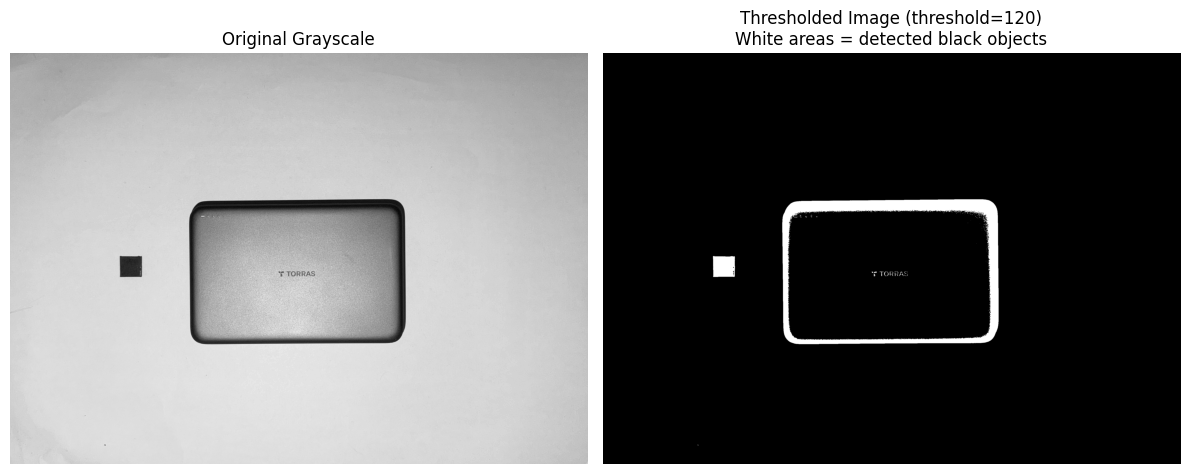

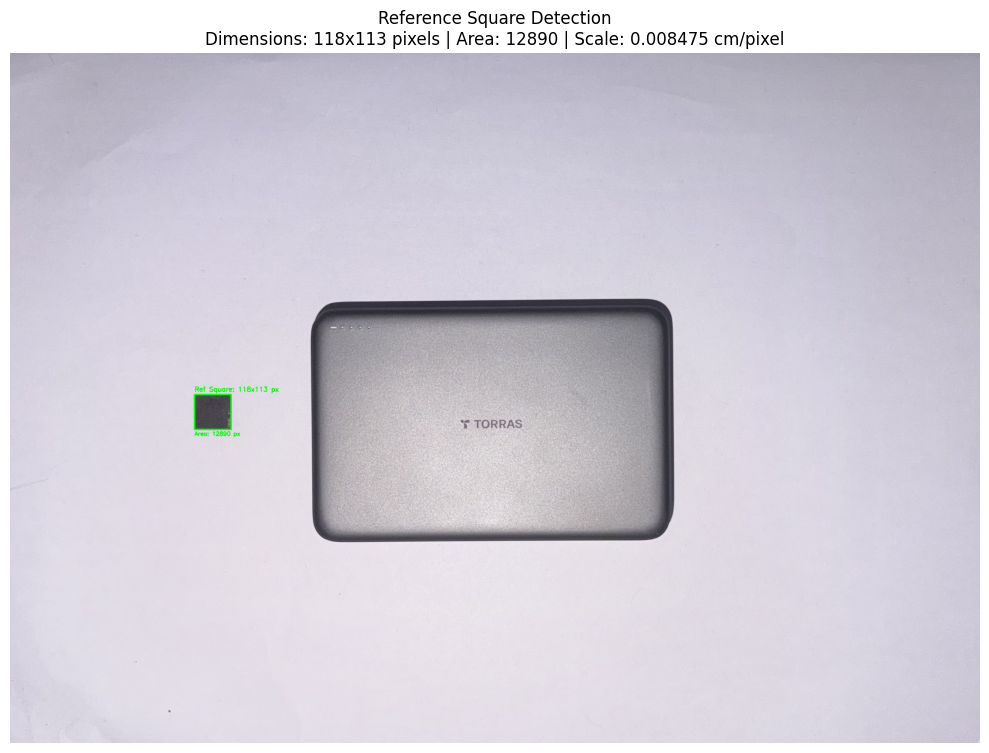

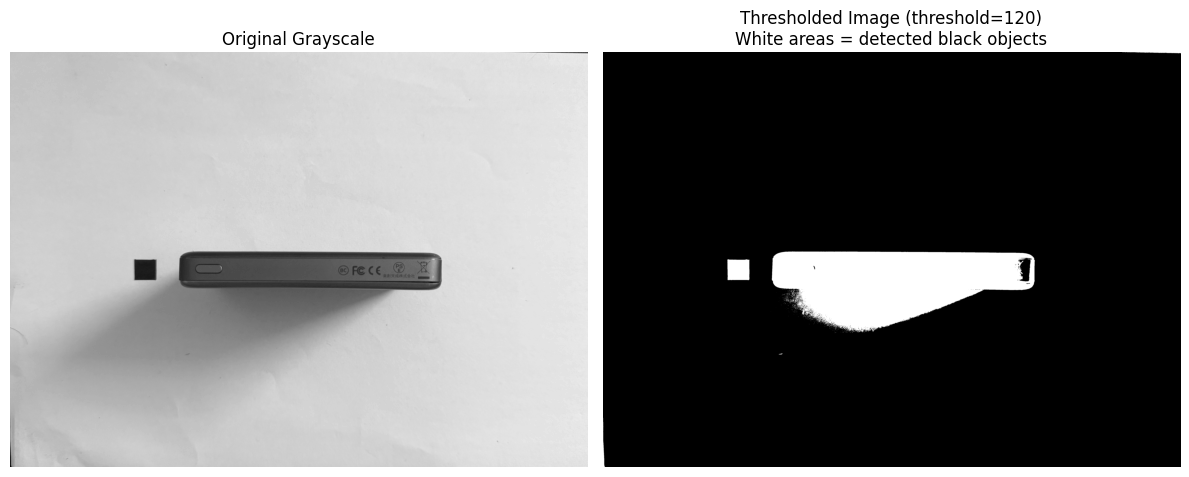

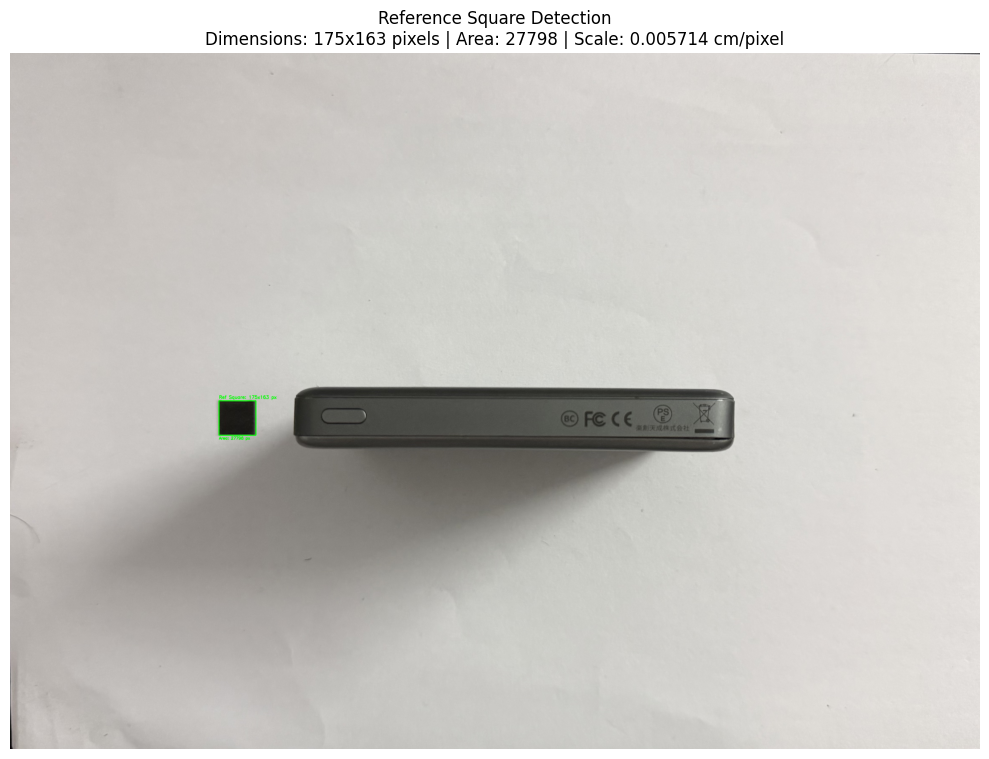

Top scale:  0.008475 cm/pixel
Side scale: 0.005714 cm/pixel
Scale mismatch (%): 38.91%


In [45]:
top_scale_cm, top_ref_size_px = compute_scale_from_ref(top_view, real_size_cm=1.0, debug=True)
side_scale_cm, side_ref_size_px = compute_scale_from_ref(side_view, real_size_cm=1.0, debug=True)

print(f"Top scale:  {top_scale_cm:.6f} cm/pixel")
print(f"Side scale: {side_scale_cm:.6f} cm/pixel")
print(f"Scale mismatch (%): {abs(top_scale_cm - side_scale_cm) / ((top_scale_cm + side_scale_cm)/2) * 100:.2f}%")

In [46]:
def segment_object(img, view_name="view", debug=True, ref_square_size_px=None):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)
    kernel = np.ones((5, 5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError(f"No contours found for {view_name}.")

    # Filter out the reference square if its size is provided
    filtered_contours = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h if h != 0 else 0
        
        # Check if this is likely the reference square (roughly square-shaped with matching size)
        is_reference_square = False
        if ref_square_size_px is not None:
            # Allow 20% tolerance in size and check if it's roughly square
            size_tolerance = ref_square_size_px * 0.2
            if (abs(w - ref_square_size_px) < size_tolerance and 
                abs(h - ref_square_size_px) < size_tolerance and
                0.8 <= aspect_ratio <= 1.2):
                is_reference_square = True
        
        if not is_reference_square:
            filtered_contours.append(cnt)
    
    # Use filtered contours if available, otherwise use all contours
    contours_to_use = filtered_contours if filtered_contours else contours
    
    largest = max(contours_to_use, key=cv2.contourArea)
    hull = cv2.convexHull(largest)  # solid boundary approximation

    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [largest], -1, 255, -1)

    if debug:
        overlay = img.copy()
        cv2.drawContours(overlay, [largest], -1, (0, 255, 255), 2)
        cv2.drawContours(overlay, [hull], -1, (0, 255, 0), 2)

        x, y, w, h = cv2.boundingRect(largest)
        cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 0, 0), 2)

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title(f"{view_name}: Grayscale")
        axes[0].axis('off')

        axes[1].imshow(edges, cmap='gray')
        axes[1].set_title(f"{view_name}: Canny Edges")
        axes[1].axis('off')

        axes[2].imshow(closed, cmap='gray')
        axes[2].set_title(f"{view_name}: Morphology Closed")
        axes[2].axis('off')

        axes[3].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[3].set_title(f"{view_name}: Boundary (yellow) + Solid hull (green)")
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    return {
        "mask": mask,
        "contour": largest,
        "hull": hull
    }


def compute_volume_from_boundaries(top_seg, side_seg, top_scale_cm, side_scale_cm, debug=True):
    top_contour = top_seg["contour"]
    top_hull = top_seg["hull"]
    side_contour = side_seg["contour"]
    side_hull = side_seg["hull"]

    # Top area from solid boundary (convex hull) to reduce noise sensitivity
    top_area_px_raw = cv2.contourArea(top_contour)
    top_area_px_hull = cv2.contourArea(top_hull)
    top_area_cm2 = top_area_px_hull * (top_scale_cm ** 2)

    # Side height from solid boundary vertical span (robust simple geometric measure)
    side_hull_pts = side_hull.reshape(-1, 2)
    y_min = int(np.min(side_hull_pts[:, 1]))
    y_max = int(np.max(side_hull_pts[:, 1]))
    side_height_px = y_max - y_min
    side_height_cm = side_height_px * side_scale_cm

    volume_cm3 = top_area_cm2 * side_height_cm

    print("--- Boundary-based Measurement Transparency ---")
    print(f"Top area (raw contour): {top_area_px_raw:.1f} px^2")
    print(f"Top area (solid hull):  {top_area_px_hull:.1f} px^2")
    print(f"Top area used:          {top_area_cm2:.4f} cm^2")
    print(f"Side height used:       {side_height_px} px  |  {side_height_cm:.4f} cm")
    print(f"Volume = Area x Height: {volume_cm3:.4f} cm^3")

    if debug:
        top_mask = top_seg["mask"]
        side_mask = side_seg["mask"]

        top_vis = cv2.cvtColor(top_mask, cv2.COLOR_GRAY2BGR)
        side_vis = cv2.cvtColor(side_mask, cv2.COLOR_GRAY2BGR)

        cv2.drawContours(top_vis, [top_contour], -1, (0, 255, 255), 2)
        cv2.drawContours(top_vis, [top_hull], -1, (0, 255, 0), 2)
        xt, yt, wt, ht = cv2.boundingRect(top_hull)
        cv2.putText(top_vis, f"Area used: {top_area_cm2:.2f} cm^2", (xt, max(yt - 10, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        cv2.drawContours(side_vis, [side_contour], -1, (0, 255, 255), 2)
        cv2.drawContours(side_vis, [side_hull], -1, (0, 255, 0), 2)

        # draw height line at median x of hull
        x_med = int(np.median(side_hull_pts[:, 0]))
        cv2.line(side_vis, (x_med, y_min), (x_med, y_max), (0, 0, 255), 2)
        cv2.putText(side_vis, f"Height: {side_height_cm:.2f} cm", (x_med + 8, y_min + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        axes[0].imshow(cv2.cvtColor(top_vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Top: boundary (yellow) + solid hull (green)")
        axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(side_vis, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Side: boundary (yellow) + hull (green) + height line (red)")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return volume_cm3


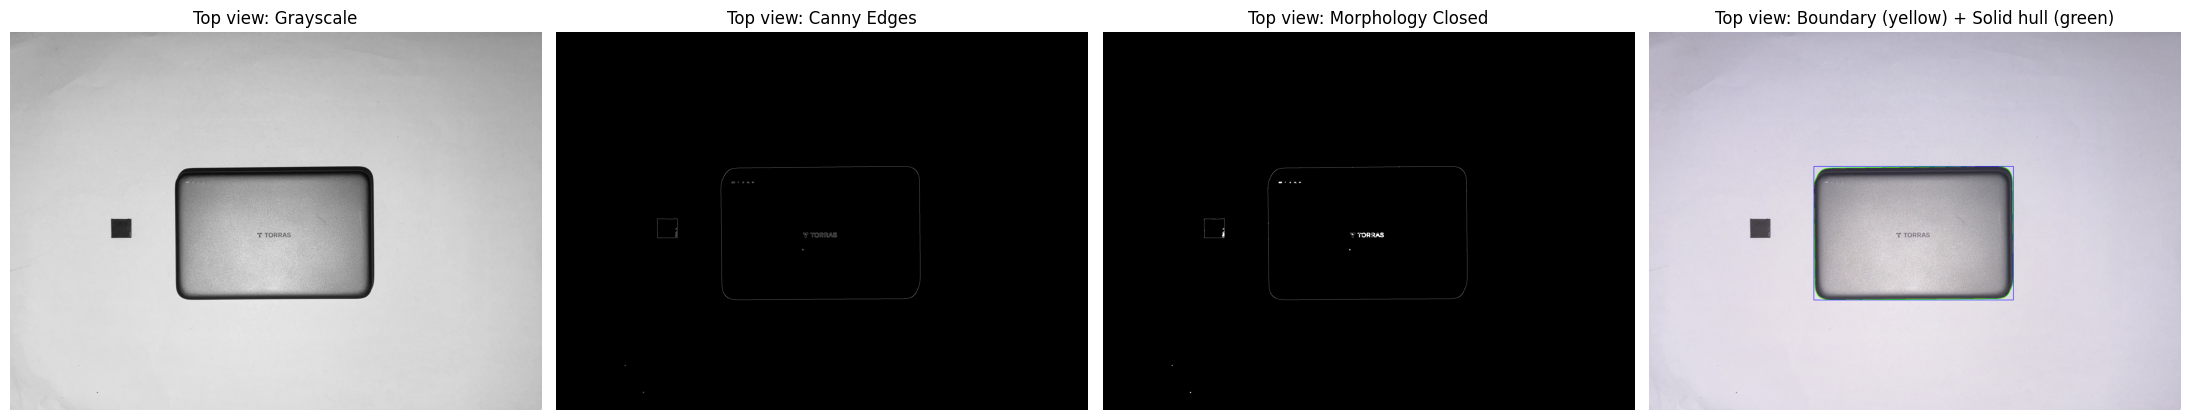

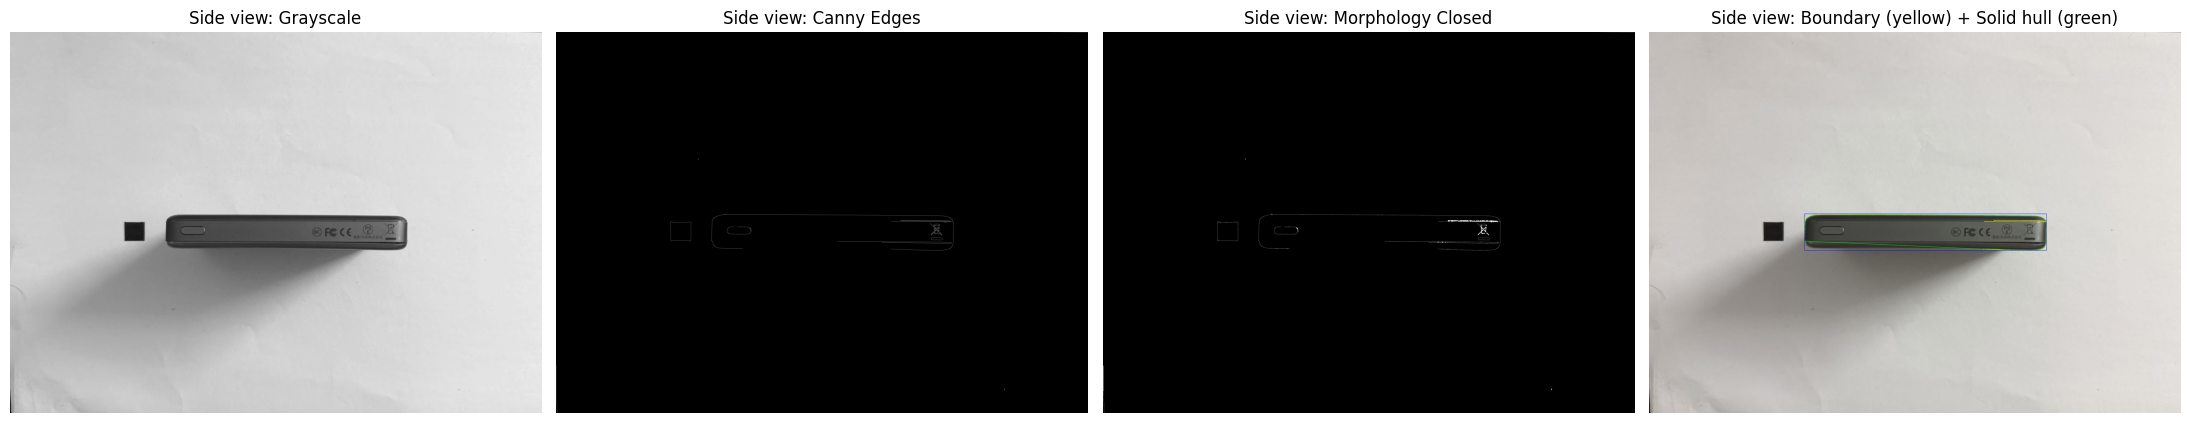

--- Boundary-based Measurement Transparency ---
Top area (raw contour): 907865.5 px^2
Top area (solid hull):  909997.0 px^2
Top area used:          65.3546 cm^2
Side height used:       315 px  |  1.8000 cm
Volume = Area x Height: 117.6382 cm^3


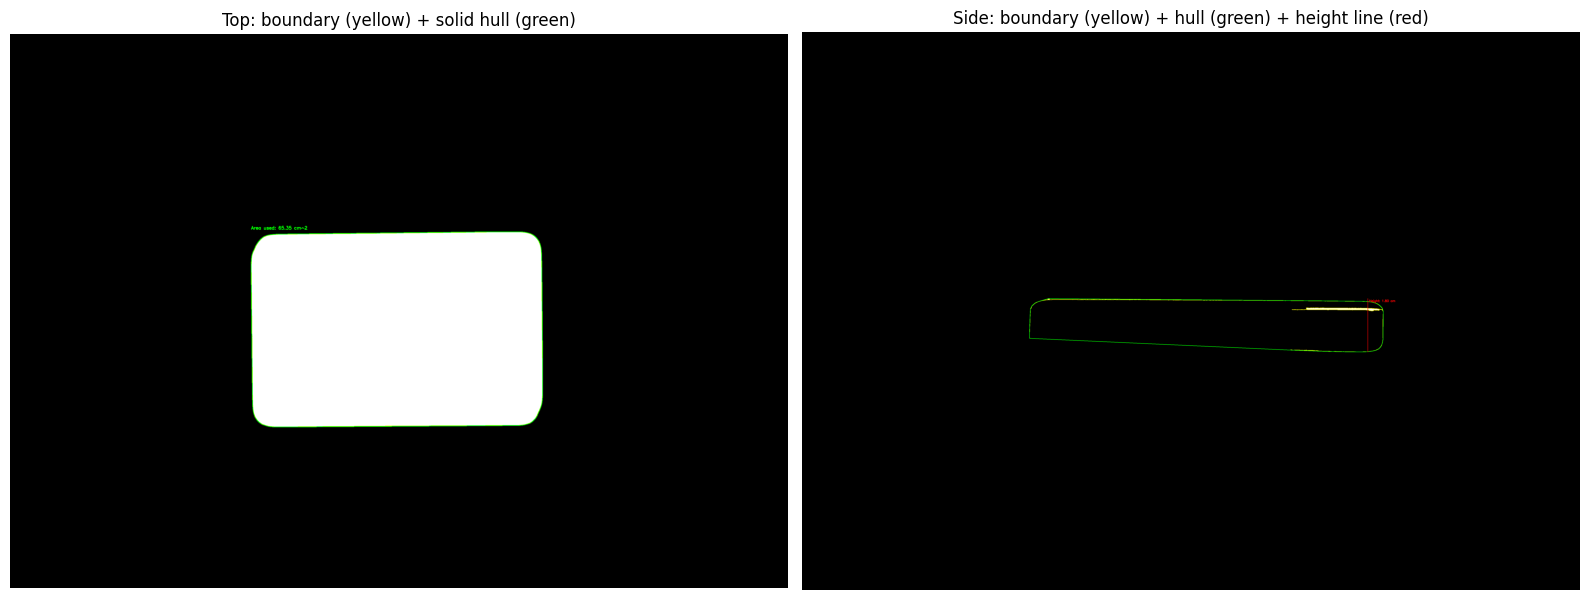

Estimated Volume (cm^3): 117.63822177535192


In [47]:
top_seg = segment_object(top_view, view_name="Top view", debug=True, ref_square_size_px=top_ref_size_px)
side_seg = segment_object(side_view, view_name="Side view", debug=True, ref_square_size_px=side_ref_size_px)

volume = compute_volume_from_boundaries(
    top_seg=top_seg,
    side_seg=side_seg,
    top_scale_cm=top_scale_cm,
    side_scale_cm=side_scale_cm,
    debug=True
)

print("Estimated Volume (cm^3):", volume)


#### Weight + Density

In [48]:
weight = 4000  # grams

In [49]:
density = weight / volume  # g/cm^3
print(f"Estimated Density: {density:.4f} g/cm^3")

Estimated Density: 34.0026 g/cm^3


#### Purity Analysis

In [50]:
# Method 1: Using the polynomial formula
def density_to_karat_formula(D):
    """Calculate karat from density using polynomial formula"""
    K = 0.0089 * D**3 - 0.550 * D**2 + 12.5299 * D - 77.06
    return K

# Method 2: Density ranges for different karats
karat_density_ranges = {
    24: (19.31, 19.51),
    22: (17.45, 18.24),
    20: (16.03, 17.11),
    18: (14.84, 16.12),
    14: (12.91, 14.44),
    10: (11.42, 13.09)
}

# Calculate karat using formula
karat_from_formula = density_to_karat_formula(density)

print("=" * 60)
print("PURITY ANALYSIS RESULTS")
print("=" * 60)
print(f"\nMeasured Density: {density:.4f} g/cm³")
print(f"\nMethod 1 - Polynomial Formula:")
print(f"  Estimated Karat: {karat_from_formula:.2f}K")

# Find closest match in density ranges
print(f"\nMethod 2 - Density Range Classification:")
found_match = False
for karat, (min_d, max_d) in sorted(karat_density_ranges.items(), reverse=True):
    if min_d <= density <= max_d:
        print(f"  ✓ Matches K{karat} range ({min_d} - {max_d} g/cm³)")
        found_match = True
        break

if not found_match:
    # Find closest range
    closest_karat = None
    min_distance = float('inf')
    for karat, (min_d, max_d) in karat_density_ranges.items():
        mid_d = (min_d + max_d) / 2
        distance = abs(density - mid_d)
        if distance < min_distance:
            min_distance = distance
            closest_karat = karat
    
    if closest_karat:
        min_d, max_d = karat_density_ranges[closest_karat]
        if density < min_d:
            print(f"  → Below K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")
        else:
            print(f"  → Above K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")

print("=" * 60)

PURITY ANALYSIS RESULTS

Measured Density: 34.0026 g/cm³

Method 1 - Polynomial Formula:
  Estimated Karat: 62.98K

Method 2 - Density Range Classification:
  → Above K24 range (closest: 19.31 - 19.51 g/cm³)


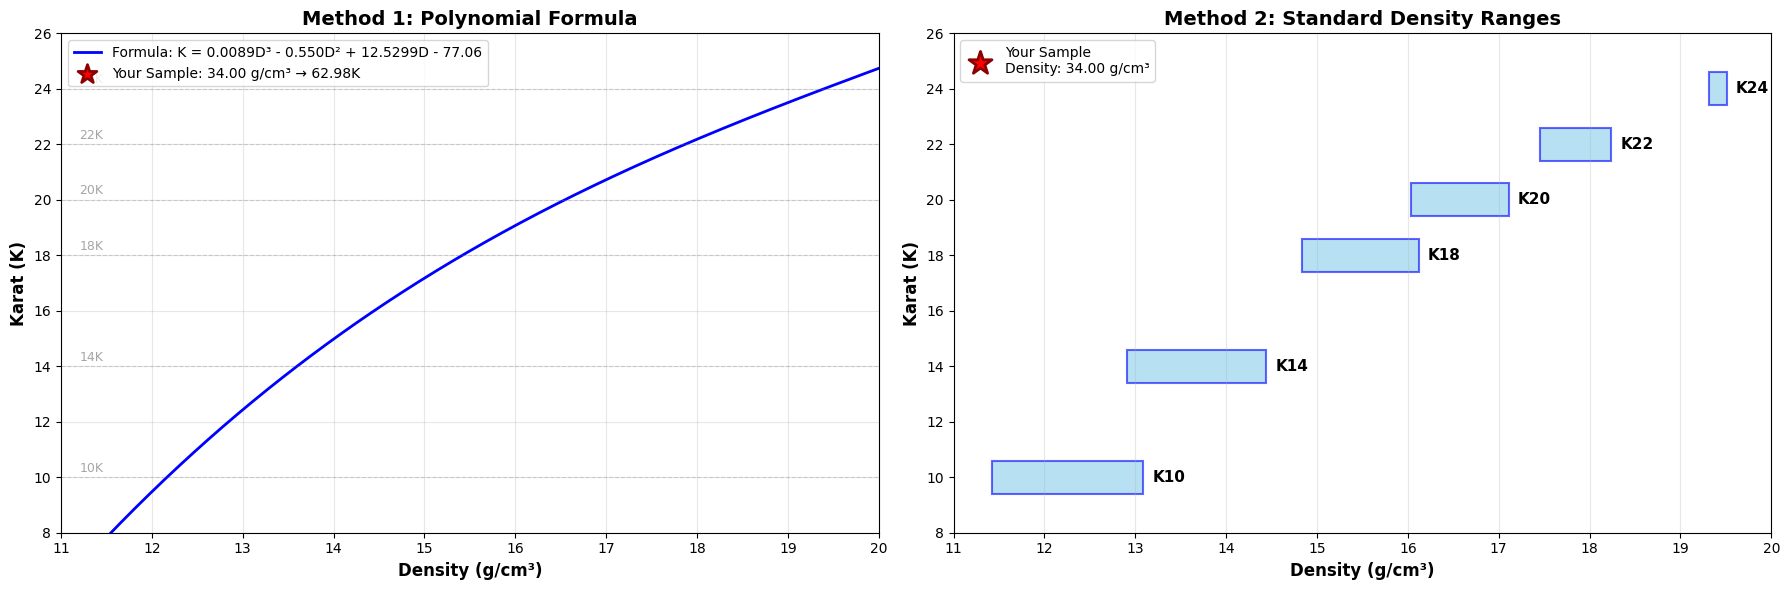


📊 Visualization complete! Both methods are displayed above.


In [51]:
# Create visualization of density-karat relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Polynomial Formula Curve
densities_range = np.linspace(11, 20, 500)
karats_formula = [density_to_karat_formula(d) for d in densities_range]

ax1.plot(densities_range, karats_formula, 'b-', linewidth=2, label='Formula: K = 0.0089D³ - 0.550D² + 12.5299D - 77.06')
ax1.scatter([density], [karat_from_formula], color='red', s=200, zorder=5, marker='*', 
            edgecolors='darkred', linewidth=2, label=f'Your Sample: {density:.2f} g/cm³ → {karat_from_formula:.2f}K')

# Add horizontal lines for standard karats
for k in [10, 14, 18, 20, 22, 24]:
    ax1.axhline(y=k, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.text(11.2, k + 0.2, f'{k}K', fontsize=9, color='gray', alpha=0.7)

ax1.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax1.set_title('Method 1: Polynomial Formula', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xlim(11, 20)
ax1.set_ylim(8, 26)

# Plot 2: Density Range Classification
karat_values = sorted(karat_density_ranges.keys())
min_densities = [karat_density_ranges[k][0] for k in karat_values]
max_densities = [karat_density_ranges[k][1] for k in karat_values]
mid_densities = [(karat_density_ranges[k][0] + karat_density_ranges[k][1]) / 2 for k in karat_values]

# Plot density ranges as horizontal bars
for i, karat in enumerate(karat_values):
    min_d, max_d = karat_density_ranges[karat]
    ax2.barh(karat, max_d - min_d, left=min_d, height=1.2, 
             alpha=0.6, color='skyblue', edgecolor='blue', linewidth=1.5)
    ax2.text(max_d + 0.1, karat, f'K{karat}', fontsize=11, va='center', fontweight='bold')

# Plot sample point
ax2.scatter([density], [karat_from_formula], color='red', s=300, zorder=5, marker='*',
            edgecolors='darkred', linewidth=2, label=f'Your Sample\nDensity: {density:.2f} g/cm³')

# Add vertical line for sample density
ax2.axvline(x=density, color='red', linestyle='--', alpha=0.5, linewidth=2)

ax2.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax2.set_title('Method 2: Standard Density Ranges', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend(loc='best', fontsize=10)
ax2.set_xlim(11, 20)
ax2.set_ylim(8, 26)

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete! Both methods are displayed above.")